In [1]:
from pathlib import Path

sorted(Path("/home/jszhao/econ470/a0/work/peerreview/data/output").glob("*"))


[PosixPath('/home/jszhao/econ470/a0/work/peerreview/data/output/.ipynb_checkpoints'),
 PosixPath('/home/jszhao/econ470/a0/work/peerreview/data/output/hwk5_analytic_2014_vs_never.csv'),
 PosixPath('/home/jszhao/econ470/a0/work/peerreview/data/output/hwk5_analytic_all_states.csv')]

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

root = Path("/home/jszhao/econ470/a0/work/peerreview")
data_dir = root / "data" / "output"

analytic = pd.read_csv(data_dir / "hwk5_analytic_all_states.csv")
analytic_2014_never = pd.read_csv(data_dir / "hwk5_analytic_2014_vs_never.csv")

analytic.shape, analytic_2014_never.shape


((55306, 62), (40272, 62))

In [3]:
analytic.groupby("year")["uncomp_care_mil"].agg(["count", "mean", "median"])


,count,mean,median
year,,,
2010,0,NaN,NaN
2011,2356,21.241028,5.407991
2012,2586,22.373213,5.101548
2013,2692,23.653667,5.668147
2014,2646,21.196400,4.449141
2015,2667,18.835321,3.652166
2016,2720,22.363417,4.323597
2017,2505,26.071830,5.281969
2018,1928,24.841174,4.391181


In [4]:
q1 = (
    analytic.groupby("year", as_index=False)["uncomp_care_mil"]
    .mean()
    .rename(columns={"uncomp_care_mil": "mean_uncomp_care_mil"})
)

q1 = q1.dropna(subset=["mean_uncomp_care_mil"]).copy()
q1["mean_uncomp_care_mil"] = q1["mean_uncomp_care_mil"].round(3)
q1


,year,mean_uncomp_care_mil
1,2011,21.241
2,2012,22.373
3,2013,23.654
4,2014,21.196
5,2015,18.835
6,2016,22.363
7,2017,26.072
8,2018,24.841


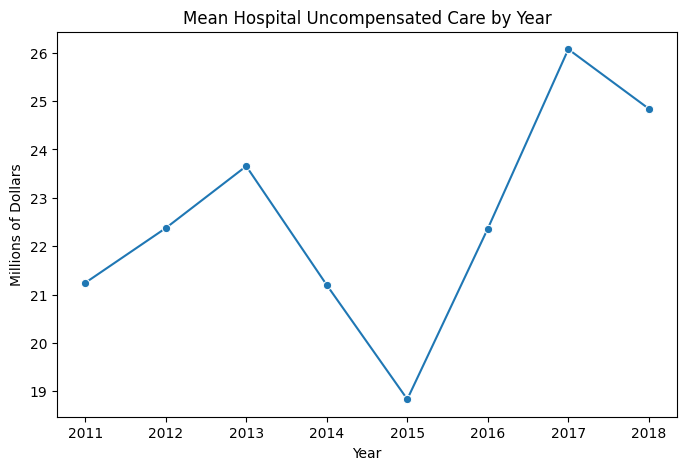

In [5]:
plt.figure(figsize=(8,5))
sns.lineplot(data=q1, x="year", y="mean_uncomp_care_mil", marker="o")
plt.title("Mean Hospital Uncompensated Care by Year")
plt.xlabel("Year")
plt.ylabel("Millions of Dollars")
plt.show()


In [6]:
q2 = (
    analytic_2014_never
    .groupby(["year", "expanded_2014"], as_index=False)["uncomp_care_mil"]
    .mean()
)

q2["group"] = np.where(
    q2["expanded_2014"] == 1,
    "Expanded in 2014",
    "Never expanded"
)

q2 = q2.dropna(subset=["uncomp_care_mil"]).copy()
q2


,year,expanded_2014,uncomp_care_mil,group
2,2011,0,26.376305,Never expanded
3,2011,1,21.493268,Expanded in 2014
4,2012,0,28.319716,Never expanded
5,2012,1,22.285446,Expanded in 2014
6,2013,0,29.648583,Never expanded
7,2013,1,23.863405,Expanded in 2014
8,2014,0,31.572412,Never expanded
9,2014,1,16.734037,Expanded in 2014
10,2015,0,30.410829,Never expanded
11,2015,1,12.270419,Expanded in 2014


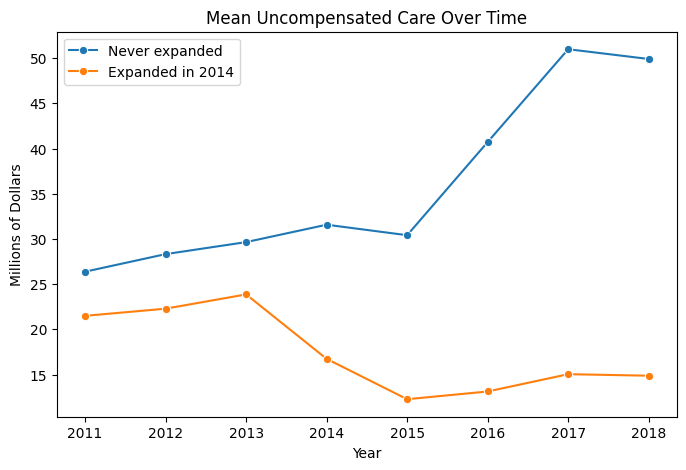

In [7]:
plt.figure(figsize=(8,5))
sns.lineplot(data=q2, x="year", y="uncomp_care_mil", hue="group", marker="o")
plt.title("Mean Uncompensated Care Over Time")
plt.xlabel("Year")
plt.ylabel("Millions of Dollars")
plt.legend(title="")
plt.show()


In [8]:
q3 = analytic_2014_never[
    analytic_2014_never["year"].isin([2012, 2015])
].copy()

q3_table = (
    q3.groupby(["expanded_2014", "year"], as_index=False)["uncomp_care_mil"]
    .mean()
)

q3_table["group"] = np.where(
    q3_table["expanded_2014"] == 1,
    "Expanded in 2014",
    "Never expanded"
)

q3_pivot = q3_table.pivot(index="group", columns="year", values="uncomp_care_mil")
q3_pivot["Change"] = q3_pivot[2015] - q3_pivot[2012]
q3_pivot


year,2012,2015,Change
group,,,
Expanded in 2014,22.285446,12.270419,-10.015027
Never expanded,28.319716,30.410829,2.091113


In [9]:
pre_treat = q3_pivot.loc["Expanded in 2014", 2012]
post_treat = q3_pivot.loc["Expanded in 2014", 2015]
pre_control = q3_pivot.loc["Never expanded", 2012]
post_control = q3_pivot.loc["Never expanded", 2015]

dd_estimate = (post_treat - pre_treat) - (post_control - pre_control)
dd_estimate


np.float64(-12.106140077277688)

In [10]:
reg5_data = analytic_2014_never.copy()
reg5_data = reg5_data.dropna(subset=["uncomp_care_mil"]).copy()

model5 = smf.ols(
    "uncomp_care_mil ~ expanded_2014 + post + expanded_2014:post",
    data=reg5_data
).fit()

print(model5.summary())
print("coef =", model5.params["expanded_2014:post"])
print("se   =", model5.bse["expanded_2014:post"])
print("pval =", model5.pvalues["expanded_2014:post"])


                            OLS Regression Results                            
Dep. Variable:        uncomp_care_mil   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     86.33
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           2.22e-55
Time:                        15:09:56   Log-Likelihood:                -85959.
No. Observations:               14981   AIC:                         1.719e+05
Df Residuals:                   14977   BIC:                         1.720e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             28.2440      1

In [11]:
reg6_data = analytic_2014_never.copy()
reg6_data = reg6_data.dropna(subset=["uncomp_care_mil"]).copy()

model6 = smf.ols(
    "uncomp_care_mil ~ expanded_2014:post + C(provider_number) + C(year)",
    data=reg6_data
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg6_data["state"]}
)

print("coef =", model6.params["expanded_2014:post"])
print("se   =", model6.bse["expanded_2014:post"])
print("pval =", model6.pvalues["expanded_2014:post"])


coef = -22.8318916143913
se   = 4.857354240769323
pval = 2.595519453024926e-06


In [12]:
reg7_data = analytic.copy()
reg7_data = reg7_data.dropna(subset=["uncomp_care_mil"]).copy()

model7 = smf.ols(
    "uncomp_care_mil ~ expanded_2014:post + C(provider_number) + C(year)",
    data=reg7_data
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg7_data["state"]}
)

print("coef =", model7.params["expanded_2014:post"])
print("se   =", model7.bse["expanded_2014:post"])
print("pval =", model7.pvalues["expanded_2014:post"])


coef = -17.581710228586505
se   = 4.228337934614177
pval = 3.20952630896793e-05


In [13]:
reg8_data = analytic_2014_never.copy()
reg8_data = reg8_data.dropna(subset=["uncomp_care_mil"]).copy()

reg8_data["event_time"] = reg8_data["year"] - 2014
reg8_data["treat_2014"] = reg8_data["expanded_2014"]

event_map = {
    -3: "event_m3",
    -2: "event_m2",
     0: "event_0",
     1: "event_1",
     2: "event_2",
     3: "event_3",
     4: "event_4"
}

for e, name in event_map.items():
    reg8_data[name] = (
        (reg8_data["event_time"] == e) & (reg8_data["treat_2014"] == 1)
    ).astype(int)


In [14]:
event_terms = " + ".join(event_map.values())

formula8 = f"uncomp_care_mil ~ {event_terms} + C(provider_number) + C(year)"
formula8


'uncomp_care_mil ~ event_m3 + event_m2 + event_0 + event_1 + event_2 + event_3 + event_4 + C(provider_number) + C(year)'

In [15]:
model8 = smf.ols(
    formula8,
    data=reg8_data
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg8_data["state"]}
)


In [16]:
event_rows = []

for e, name in event_map.items():
    coef = model8.params[name]
    se = model8.bse[name]
    event_rows.append({
        "event_time": e,
        "coef": coef,
        "se": se,
        "lower": coef - 1.96 * se,
        "upper": coef + 1.96 * se
    })

event_df = pd.DataFrame(event_rows).sort_values("event_time")
event_df


,event_time,coef,se,lower,upper
0,-3,3.526472,1.774840,0.047785,7.005159
1,-2,1.778876,1.671100,-1.496481,5.054232
2,0,-7.856634,2.189894,-12.148827,-3.564442
3,1,-12.651791,3.553394,-19.616444,-5.687138
4,2,-23.428869,4.882874,-32.999302,-13.858437
5,3,-34.604182,7.122603,-48.564482,-20.643881
6,4,-39.029038,7.760159,-54.238950,-23.819127


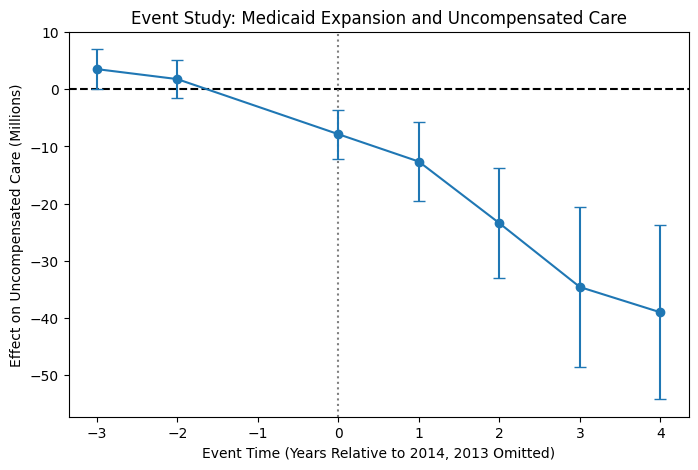

In [17]:
plt.figure(figsize=(8,5))
plt.axhline(0, color="black", linestyle="--")
plt.axvline(0, color="gray", linestyle=":")
plt.errorbar(
    event_df["event_time"],
    event_df["coef"],
    yerr=1.96 * event_df["se"],
    fmt="o-",
    capsize=4
)
plt.title("Event Study: Medicaid Expansion and Uncompensated Care")
plt.xlabel("Event Time (Years Relative to 2014, 2013 Omitted)")
plt.ylabel("Effect on Uncompensated Care (Millions)")
plt.show()


In [18]:
reg9_data = analytic.copy()
reg9_data = reg9_data.dropna(subset=["uncomp_care_mil", "expansion_year"]).copy()
reg9_data = reg9_data[reg9_data["expanded"] == 1].copy()


In [19]:
reg9_data["event_time"] = reg9_data["year"] - reg9_data["expansion_year"]


In [20]:
reg9_data["event_time_binned"] = reg9_data["event_time"].clip(lower=-3, upper=4)


In [21]:
event_map9 = {
    -3: "event_m3",
    -2: "event_m2",
     0: "event_0",
     1: "event_1",
     2: "event_2",
     3: "event_3",
     4: "event_4"
}

for e, name in event_map9.items():
    reg9_data[name] = (reg9_data["event_time_binned"] == e).astype(int)


In [22]:
event_terms9 = " + ".join(event_map9.values())
formula9 = f"uncomp_care_mil ~ {event_terms9} + C(provider_number) + C(year)"
formula9


'uncomp_care_mil ~ event_m3 + event_m2 + event_0 + event_1 + event_2 + event_3 + event_4 + C(provider_number) + C(year)'

In [23]:
model9 = smf.ols(
    formula9,
    data=reg9_data
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg9_data["state"]}
)


In [24]:
event_rows9 = []

for e, name in event_map9.items():
    coef = model9.params[name]
    se = model9.bse[name]
    event_rows9.append({
        "event_time": e,
        "coef": coef,
        "se": se,
        "lower": coef - 1.96 * se,
        "upper": coef + 1.96 * se
    })

event_df9 = pd.DataFrame(event_rows9).sort_values("event_time")
event_df9


,event_time,coef,se,lower,upper
0,-3,-1.100968,1.323368,-3.694770,1.492834
1,-2,-0.012836,0.744979,-1.472996,1.447323
2,0,-6.549883,1.758578,-9.996695,-3.103070
3,1,-13.862785,2.934811,-19.615014,-8.110556
4,2,-17.181820,3.168014,-23.391127,-10.972512
5,3,-17.494314,3.405639,-24.169367,-10.819261
6,4,-16.418772,3.866620,-23.997348,-8.840196


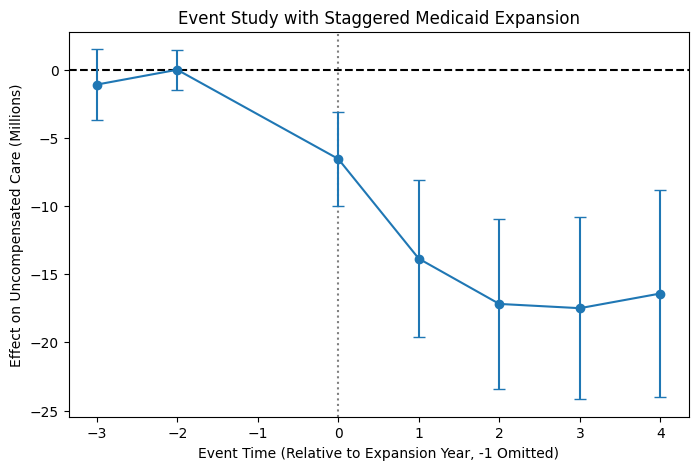

In [25]:
plt.figure(figsize=(8,5))
plt.axhline(0, color="black", linestyle="--")
plt.axvline(0, color="gray", linestyle=":")
plt.errorbar(
    event_df9["event_time"],
    event_df9["coef"],
    yerr=1.96 * event_df9["se"],
    fmt="o-",
    capsize=4
)
plt.title("Event Study with Staggered Medicaid Expansion")
plt.xlabel("Event Time (Relative to Expansion Year, -1 Omitted)")
plt.ylabel("Effect on Uncompensated Care (Millions)")
plt.show()
